In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

fund = pd.read_csv("../data/processed/fund_master_clean.csv")

perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [4]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64



## Daily Return Validation

The daily return distribution appears reasonable. The average daily return is positive (0.063%) with a standard deviation of approximately 1.03%. The largest daily loss observed was -5.81% while the highest daily gain was 6.47%, indicating realistic market volatility.

In [6]:
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

nav["drawdown"] = (
    nav["nav"] / nav["running_max"] - 1
)

max_dd = (
    nav.groupby("amfi_code")["drawdown"]
       .min()
       .reset_index()
)

max_dd.columns = [
    "amfi_code",
    "max_drawdown"
]

max_dd.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [8]:
nav["date"] = pd.to_datetime(nav["date"])

In [9]:
cagr_list = []

for code, group in nav.groupby("amfi_code"):

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"] -
         group.iloc[0]["date"]).days
    ) / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_list.append(
        [code, round(cagr * 100, 2)]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.sort_values(
    "cagr_pct",
    ascending=False
).head(10)

,amfi_code,cagr_pct
25,120505,32.83
21,119598,32.42
39,149324,32.29
36,148569,31.95
34,148567,30.97
30,120843,30.91
2,100033,30.12
38,149323,29.58
16,119094,28.21
19,119551,25.80


## CAGR Analysis

The highest-performing schemes delivered CAGR values above 30%, indicating strong long-term wealth creation potential. Fund 120505 recorded the highest CAGR of 32.83% during the analysis period.

In [10]:
rf_daily = 0.065 / 252

sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(["mean", "std"])
       .reset_index()
)

sharpe["sharpe_ratio"] = (
    (sharpe["mean"] - rf_daily)
    / sharpe["std"]
) * np.sqrt(252)

sharpe = sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe[
    ["amfi_code","sharpe_ratio"]
].head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


## Sharpe Ratio Analysis

The Sharpe Ratio evaluates risk-adjusted performance by comparing excess returns to total volatility. Higher Sharpe values indicate better returns per unit of risk taken.

In [11]:
rf_daily = 0.065 / 252

sortino_list = []

for code, group in nav.groupby("amfi_code"):

    mean_return = group["daily_return"].mean()

    downside = group.loc[
        group["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside.std()

    sortino = (
        (mean_return - rf_daily)
        / downside_std
    ) * np.sqrt(252)

    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


## Sortino Ratio Analysis

The Sortino Ratio evaluates risk-adjusted performance using only downside volatility. It focuses on harmful fluctuations and provides a clearer measure of investment quality than the Sharpe Ratio.

In [12]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [13]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [14]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [17]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [18]:
from scipy.stats import linregress

alpha_beta = []

for code, fund_data in nav.groupby("amfi_code"):

    merged = pd.merge(
        fund_data[
            ["date", "daily_return"]
        ],
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [19]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [21]:
perf.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [22]:
# 1. Start with performance table

scorecard = perf.copy()

# 2. Rank metrics

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

# Lower expense ratio is better
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

# Lower drawdown is better
scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(
    ascending=True
)

# 3. Weighted score

scorecard["fund_score"] = (
      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["drawdown_rank"] * 0.10
)

# Convert to 0–100 scale

scorecard["fund_score"] = (
    100 -
    (
        (scorecard["fund_score"] -
         scorecard["fund_score"].min())
        /
        (
            scorecard["fund_score"].max()
            -
            scorecard["fund_score"].min()
        )
    ) * 100
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    ["amfi_code",
     "scheme_name",
     "fund_score"]
].head(10)

,amfi_code,scheme_name,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,97.422680
21,120842,Kotak Emerging Equity Fund - Regular - Growth,95.360825
29,101207,ABSL Small Cap Fund - Regular - Growth,90.721649
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.731959
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,81.829897
9,100025,HDFC Short Term Debt Fund - Regular - Growth,79.896907
14,120507,ICICI Pru Liquid Fund - Regular - Growth,77.319588
12,120505,ICICI Pru Midcap Fund - Regular - Growth,75.773196
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,72.938144


In [23]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [25]:
top5 = scorecard.nlargest(
    5,
    "fund_score"
)

top5[
    ["amfi_code",
     "scheme_name",
     "fund_score"]
]

,amfi_code,scheme_name,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,97.422680
21,120842,Kotak Emerging Equity Fund - Regular - Growth,95.360825
29,101207,ABSL Small Cap Fund - Regular - Growth,90.721649
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.731959


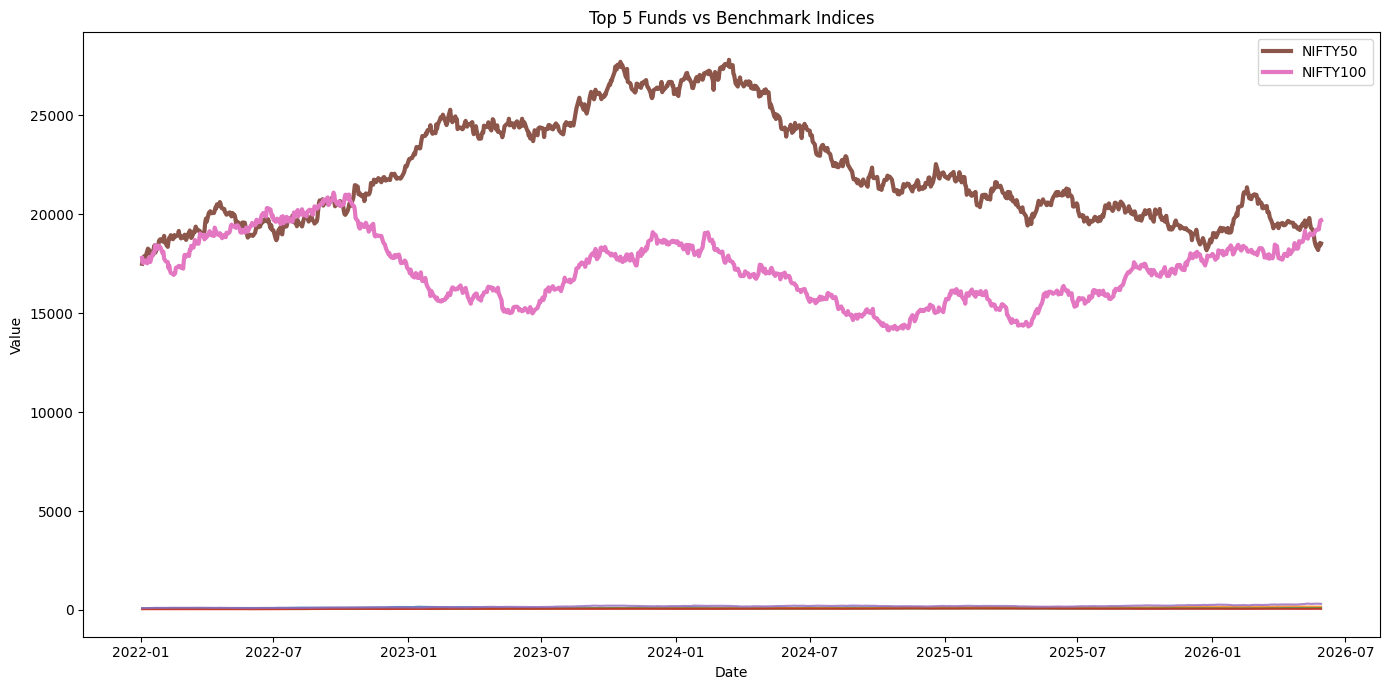

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

# Top 5 funds

for code in top5["amfi_code"]:

    fund_data = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        alpha=0.8
    )

# NIFTY50

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
]

plt.plot(
    pd.to_datetime(nifty50["date"]),
    nifty50["close_value"],
    linewidth=3,
    label="NIFTY50"
)

# NIFTY100

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

plt.plot(
    pd.to_datetime(nifty100["date"]),
    nifty100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs Benchmark Indices"
)

plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

## Benchmark Comparison

The top 5 ranked mutual funds were compared against NIFTY50 and NIFTY100 benchmark indices. The comparison helps evaluate whether the best-performing schemes outperformed broader market benchmarks over the analysis period.

In [27]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

<Figure size 640x480 with 0 Axes>